<a href="https://colab.research.google.com/github/tanusreemajumder/Neural-Networks-Andrew-Ng/blob/main/part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(1)
print("NumPy version:", np.__version__)

NumPy version: 2.1.3


## 1. Binary Classification

In binary classification we want to predict a label $y \in \{0, 1\}$ from an input vector $x$.

Classic example: given an image, predict "cat" (1) or "not cat" (0). An image of shape (64, 64, 3) is flattened into a single feature vector of size $n_x = 64 \times 64 \times 3 = 12288$.

Below we simulate this with a small synthetic dataset: 2D points, where the label depends on which side of a curve the point falls on.

X shape: (2, 400)
Y shape: (1, 400)


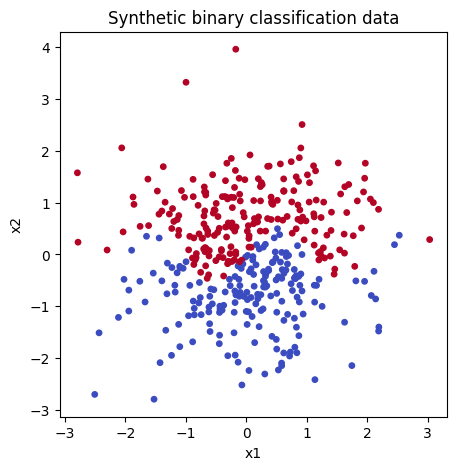

In [ ]:
def generate_dataset(m=400):
    """Generate m synthetic 2D points with binary labels."""
    X = np.random.randn(2, m)
    # A nonlinear-ish boundary so logistic regression has a real job to do
    y = (X[1, :] > 0.5 * np.sin(3 * X[0, :])).astype(int).reshape(1, m)
    return X, y

X, Y = generate_dataset(400)
print("X shape:", X.shape)   # (n_x, m) -> features stacked as COLUMNS
print("Y shape:", Y.shape)   # (1, m)

plt.figure(figsize=(5, 5))
plt.scatter(X[0, :], X[1, :], c=Y[0, :], cmap="coolwarm", s=15)
plt.title("Synthetic binary classification data")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

## 2. Logistic Regression

Given input $x \in \mathbb{R}^{n_x}$, logistic regression outputs $\hat{y} = P(y=1 \mid x)$ using parameters $w \in \mathbb{R}^{n_x}$ and $b \in \mathbb{R}$:

$$z = w^T x + b$$
$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

$\sigma$ (sigmoid) squashes any real number into $(0, 1)$, which is what makes $\hat{y}$ interpretable as a probability.

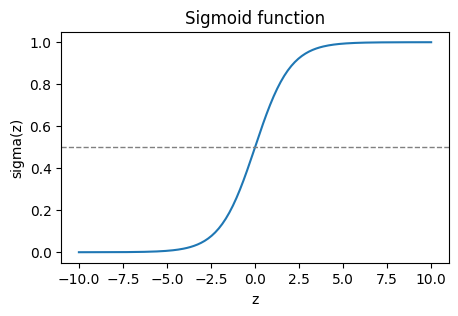

sigmoid(0)  = 0.5
sigmoid(20) = 0.9999999979388463
sigmoid(-20)= 2.0611536181902037e-09


In [ ]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

# Quick sanity check + plot of the sigmoid shape
z_vals = np.linspace(-10, 10, 200)
plt.figure(figsize=(5, 3))
plt.plot(z_vals, sigmoid(z_vals))
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.title("Sigmoid function")
plt.xlabel("z"); plt.ylabel("sigma(z)")
plt.show()

print("sigmoid(0)  =", sigmoid(0))     # should be 0.5
print("sigmoid(20) =", sigmoid(20))    # close to 1
print("sigmoid(-20)=", sigmoid(-20))   # close to 0

## 3. Logistic Regression Cost Function

For a single example, the **loss** function is:

$$\mathcal{L}(\hat{y}, y) = -\left[ y \log(\hat{y}) + (1-y)\log(1-\hat{y}) \right]$$

This is small when the prediction is confident and correct, and large when it's confident and wrong. Squared error isn't used here because it makes the optimization landscape non-convex for logistic regression.

The **cost** function averages the loss over all $m$ examples:

$$J(w, b) = \frac{1}{m} \sum_{i=1}^{m} \mathcal{L}(\hat{y}^{(i)}, y^{(i)})$$

In [ ]:
def compute_cost(Y_hat, Y, eps=1e-8):
    """Y_hat, Y: shape (1, m). Returns scalar cost J."""
    m = Y.shape[1]
    Y_hat = np.clip(Y_hat, eps, 1 - eps)  # avoid log(0)
    cost = -(1.0 / m) * np.sum(Y * np.log(Y_hat) + (1 - Y) * np.log(1 - Y_hat))
    return np.squeeze(cost)

# Sanity check with a tiny hand example
Y_test     = np.array([[1, 0, 1]])
Yhat_test  = np.array([[0.9, 0.1, 0.8]])   # good predictions -> low cost
print("Cost (good predictions):", compute_cost(Yhat_test, Y_test))

Yhat_bad = np.array([[0.1, 0.9, 0.2]])     # bad predictions -> high cost
print("Cost (bad predictions): ", compute_cost(Yhat_bad, Y_test))

Cost (good predictions): 0.14462152754328741
Cost (bad predictions):  2.0715360328073973


## 4. Gradient Descent

We want $w, b$ that minimize $J(w, b)$. Gradient descent repeatedly moves the parameters in the direction opposite the gradient:

$$w := w - \alpha \frac{\partial J}{\partial w}, \qquad b := b - \alpha \frac{\partial J}{\partial b}$$

where $\alpha$ is the learning rate. Below is a 1D illustration on a simple convex function, just to see the mechanics before applying it to logistic regression.

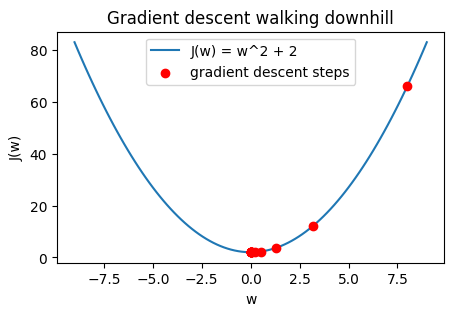

w after 15 steps: 0.0  (true minimum is w=0)


In [ ]:
def f(w):        return w**2 + 2      # a toy convex cost
def df_dw(w):     return 2 * w           # its derivative

w = 8.0          # start far from the minimum
alpha = 0.3
history = [w]

for i in range(15):
    w = w - alpha * df_dw(w)
    history.append(w)

plt.figure(figsize=(5, 3))
ws = np.linspace(-9, 9, 100)
plt.plot(ws, f(ws), label="J(w) = w^2 + 2")
plt.scatter(history, [f(w) for w in history], color="red", zorder=5, label="gradient descent steps")
plt.legend(); plt.title("Gradient descent walking downhill")
plt.xlabel("w"); plt.ylabel("J(w)")
plt.show()

print("w after 15 steps:", round(history[-1], 4), " (true minimum is w=0)")

## 5 & 6. Computation Graph, and Derivatives with a Computation Graph

A computation graph breaks a formula into elementary steps so derivatives can be computed step by step with the chain rule (this is exactly what backpropagation does).

Example, following the classic teaching example:

$$J(a, b, c) = 3(a + bc)$$

Break it down:
- $u = bc$
- $v = a + u$
- $J = 3v$

**Forward pass** computes $J$ from $a, b, c$. **Backward pass** computes $\frac{\partial J}{\partial a}, \frac{\partial J}{\partial b}, \frac{\partial J}{\partial c}$ by walking the graph right-to-left with the chain rule:

$$\frac{dJ}{dv} = 3, \qquad \frac{dJ}{du} = \frac{dJ}{dv}\cdot\frac{dv}{du} = 3 \cdot 1 = 3$$
$$\frac{dJ}{da} = \frac{dJ}{dv}\cdot\frac{dv}{da} = 3 \cdot 1 = 3$$
$$\frac{dJ}{db} = \frac{dJ}{du}\cdot\frac{du}{db} = 3 \cdot c, \qquad \frac{dJ}{dc} = \frac{dJ}{du}\cdot\frac{du}{dc} = 3 \cdot b$$

In [ ]:
a, b, c = 5.0, 3.0, 2.0

# ---- Forward pass ----
u = b * c
v = a + u
J = 3 * v
print(f"Forward pass:  u={u}, v={v}, J={J}")

# ---- Backward pass (manual chain rule) ----
dJ_dv = 3
dJ_du = dJ_dv * 1        # dv/du = 1
dJ_da = dJ_dv * 1        # dv/da = 1
dJ_db = dJ_du * c        # du/db = c
dJ_dc = dJ_du * b        # du/dc = b

print(f"Backward pass: dJ/da={dJ_da}, dJ/db={dJ_db}, dJ/dc={dJ_dc}")

# ---- Verify with numerical (finite-difference) gradients ----
eps = 1e-6
def J_of(a, b, c): return 3 * (a + b * c)
num_da = (J_of(a+eps, b, c) - J_of(a-eps, b, c)) / (2*eps)
num_db = (J_of(a, b+eps, c) - J_of(a, b-eps, c)) / (2*eps)
num_dc = (J_of(a, b, c+eps) - J_of(a, b, c-eps)) / (2*eps)
print(f"Numerical check: dJ/da={num_da:.4f}, dJ/db={num_db:.4f}, dJ/dc={num_dc:.4f}")

Forward pass:  u=6.0, v=11.0, J=33.0
Backward pass: dJ/da=3, dJ/db=6.0, dJ/dc=9.0
Numerical check: dJ/da=3.0000, dJ/db=6.0000, dJ/dc=9.0000


## 7. Logistic Regression Gradient Descent (non-vectorized, one step)

Now apply the same computation-graph idea to logistic regression, for a single example $(x, y)$ with 2 features:

$$z = w_1 x_1 + w_2 x_2 + b \;\rightarrow\; a = \sigma(z) \;\rightarrow\; \mathcal{L}(a, y)$$

The key derivatives (worth memorizing, they recur everywhere):

$$\frac{d\mathcal{L}}{da} = -\frac{y}{a} + \frac{1-y}{1-a}, \qquad \frac{d\mathcal{L}}{dz} = a - y \;\text{(this simplification is the whole reason logistic regression is convenient)}$$
$$\frac{\partial \mathcal{L}}{\partial w_1} = x_1 (a-y), \quad \frac{\partial \mathcal{L}}{\partial w_2} = x_2 (a-y), \quad \frac{\partial \mathcal{L}}{\partial b} = (a-y)$$

Below is the classic **explicit for-loop** version over all $m$ examples, exactly as it's usually first introduced before vectorizing it.

In [ ]:
def logistic_regression_loop(X, Y, num_iterations=200, alpha=0.5, print_cost=False):
    """
    Non-vectorized (explicit for-loop over features AND examples) logistic
    regression gradient descent. Intentionally slow/explicit for teaching.
    X: (n_x, m), Y: (1, m)
    """
    n_x, m = X.shape
    w = np.zeros(n_x)
    b = 0.0
    costs = []

    for it in range(num_iterations):
        J = 0.0
        dw = np.zeros(n_x)
        db = 0.0

        for i in range(m):                      # loop over training examples
            x_i = X[:, i]
            y_i = Y[0, i]

            z_i = b
            for j in range(n_x):                 # loop over features
                z_i += w[j] * x_i[j]
            a_i = sigmoid(z_i)
            J += -(y_i * np.log(a_i + 1e-8) + (1 - y_i) * np.log(1 - a_i + 1e-8))

            dz_i = a_i - y_i
            for j in range(n_x):                 # loop over features again
                dw[j] += x_i[j] * dz_i
            db += dz_i

        J  /= m
        dw /= m
        db /= m

        w -= alpha * dw
        b -= alpha * db
        costs.append(J)

        if print_cost and it % 50 == 0:
            print(f"iteration {it}: cost = {J:.4f}")

    return w, b, costs

t0 = time.time()
w_loop, b_loop, costs_loop = logistic_regression_loop(X, Y, num_iterations=200, alpha=1.2, print_cost=True)
t1 = time.time()
print(f"Loop version training time: {t1 - t0:.4f} sec")

iteration 0: cost = 0.6931
iteration 50: cost = 0.2302
iteration 100: cost = 0.2207
iteration 150: cost = 0.2183
Loop version training time: 0.5871 sec


## 8. Vectorization

Explicit `for` loops over examples/features are slow in Python. Vectorization replaces them with NumPy array operations that run in optimized, compiled C code under the hood. Same math, dramatically faster — this matters a lot once $m$ and $n_x$ get large (e.g. training on thousands of images).

A quick generic demo before applying it to logistic regression:

In [ ]:
n = 1_000_000
x1 = np.random.rand(n)
x2 = np.random.rand(n)

# --- non-vectorized dot product ---
t0 = time.time()
dot = 0.0
for i in range(n):
    dot += x1[i] * x2[i]
t1 = time.time()
print(f"Loop version:       result={dot:.4f}, time={1000*(t1-t0):.2f} ms")

# --- vectorized dot product ---
t0 = time.time()
dot_vec = np.dot(x1, x2)
t1 = time.time()
print(f"Vectorized version: result={dot_vec:.4f}, time={1000*(t1-t0):.2f} ms")

Loop version:       result=249827.5427, time=561.94 ms
Vectorized version: result=249827.5427, time=3.60 ms


## 9. Vectorizing Logistic Regression (forward pass)

For all $m$ examples at once, stack them as **columns** of $X \in \mathbb{R}^{(n_x, m)}$. Then the entire forward pass for every example is just two lines:

$$Z = w^T X + b \quad\text{(shape } (1, m)\text{, } b \text{ broadcasts to every column)}$$
$$A = \sigma(Z) \quad\text{(shape } (1, m)\text{)}$$

No loop over examples, no loop over features — `np.dot` handles both at once.

In [ ]:
def forward_propagation(w, b, X):
    """w: (n_x, 1), X: (n_x, m) -> A: (1, m)"""
    Z = np.dot(w.T, X) + b
    A = sigmoid(Z)
    return A

n_x = X.shape[0]
w0 = np.zeros((n_x, 1))
b0 = 0.0

A0 = forward_propagation(w0, b0, X)
print("A shape:", A0.shape)          # (1, m)
print("First 5 predictions:", A0[0, :5])

A shape: (1, 400)
First 5 predictions: [0.5 0.5 0.5 0.5 0.5]


## 10. Vectorizing Logistic Regression's Gradient Computation

Using $dZ = A - Y$ (the same simplification derived in section 7, now applied to *all* examples as a single row vector), the gradients over the whole dataset become:

$$dZ = A - Y \qquad \text{shape } (1, m)$$
$$dw = \frac{1}{m} X \, dZ^T \qquad \text{shape } (n_x, 1)$$
$$db = \frac{1}{m} \sum_{i=1}^{m} dZ^{(i)} \qquad \text{scalar, via } \texttt{np.sum}$$

This is the entire gradient step for logistic regression, with **zero explicit for-loops** over examples or features.

In [ ]:
def propagate(w, b, X, Y):
    """One fully vectorized forward + backward pass. Returns cost and grads."""
    m = X.shape[1]

    # forward
    A = sigmoid(np.dot(w.T, X) + b)          # (1, m)
    cost = compute_cost(A, Y)

    # backward
    dZ = A - Y                                # (1, m)
    dw = (1.0 / m) * np.dot(X, dZ.T)          # (n_x, 1)
    db = (1.0 / m) * np.sum(dZ)               # scalar

    grads = {"dw": dw, "db": db}
    return grads, cost


def logistic_regression_vectorized(X, Y, num_iterations=200, alpha=1.2, print_cost=False):
    n_x = X.shape[0]
    w = np.zeros((n_x, 1))
    b = 0.0
    costs = []

    for it in range(num_iterations):
        grads, cost = propagate(w, b, X, Y)
        w -= alpha * grads["dw"]
        b -= alpha * grads["db"]
        costs.append(cost)
        if print_cost and it % 50 == 0:
            print(f"iteration {it}: cost = {cost:.4f}")

    return w, b, costs

t0 = time.time()
w_vec, b_vec, costs_vec = logistic_regression_vectorized(X, Y, num_iterations=200, alpha=1.2, print_cost=True)
t1 = time.time()
print(f"Vectorized version training time: {t1 - t0:.4f} sec")

iteration 0: cost = 0.6931
iteration 50: cost = 0.2302
iteration 100: cost = 0.2207
iteration 150: cost = 0.2183
Vectorized version training time: 0.0980 sec


Final cost (loop version):        0.21755
Final cost (vectorized version):   0.21755


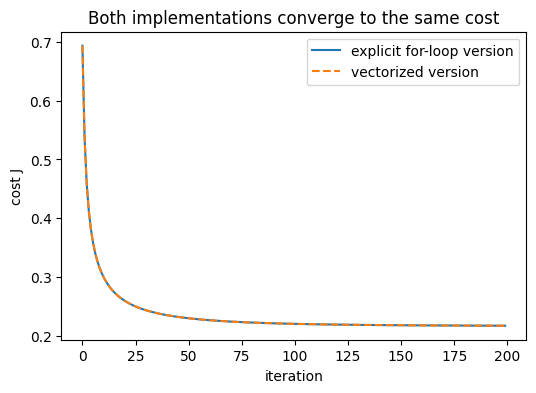

In [ ]:
# Compare loop-based vs vectorized training: same math, very different speed
print("Final cost (loop version):       ", round(costs_loop[-1], 5))
print("Final cost (vectorized version):  ", round(costs_vec[-1], 5))

plt.figure(figsize=(6, 4))
plt.plot(costs_loop, label="explicit for-loop version")
plt.plot(costs_vec, label="vectorized version", linestyle="--")
plt.xlabel("iteration"); plt.ylabel("cost J")
plt.title("Both implementations converge to the same cost")
plt.legend()
plt.show()

Training accuracy: 89.25%


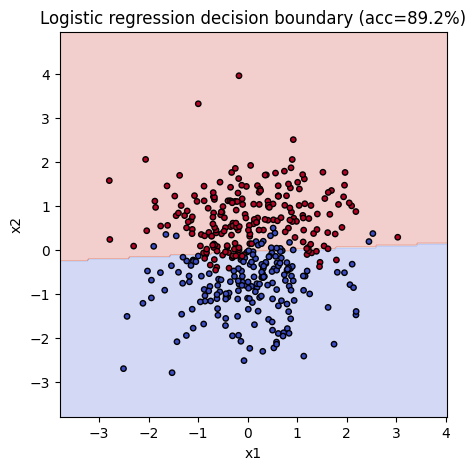

In [ ]:
def predict(w, b, X, threshold=0.5):
    A = sigmoid(np.dot(w.T, X) + b)
    return (A > threshold).astype(int)

preds = predict(w_vec, b_vec, X)
accuracy = np.mean(preds == Y) * 100
print(f"Training accuracy: {accuracy:.2f}%")

# Plot decision boundary
xx, yy = np.meshgrid(np.linspace(X[0].min()-1, X[0].max()+1, 200),
                      np.linspace(X[1].min()-1, X[1].max()+1, 200))
grid = np.c_[xx.ravel(), yy.ravel()].T
Z = predict(w_vec, b_vec, grid).reshape(xx.shape)

plt.figure(figsize=(5, 5))
plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
plt.scatter(X[0, :], X[1, :], c=Y[0, :], cmap="coolwarm", edgecolor="k", s=15)
plt.title(f"Logistic regression decision boundary (acc={accuracy:.1f}%)")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Housing.csv')

In [ ]:
print("Shape:", df.shape)
df.head()

Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
print(df.dtypes)
print("\nMissing values per column:\n", df.isna().sum())

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

Missing values per column:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


Median price: 4340000.0
expensive
0    275
1    270
Name: count, dtype: int64


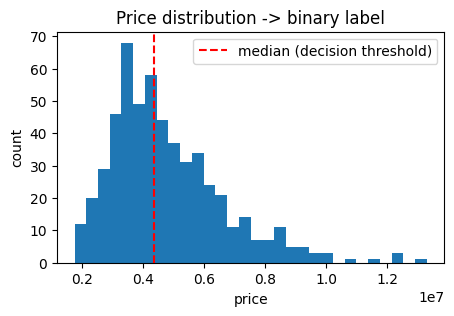

In [ ]:
# Turn the continuous price into a binary label:
# 1 = expensive (above median price), 0 = affordable (at or below median)
median_price = df["price"].median()
df["expensive"] = (df["price"] > median_price).astype(int)

print("Median price:", median_price)
print(df["expensive"].value_counts())

plt.figure(figsize=(5, 3))
plt.hist(df["price"], bins=30)
plt.axvline(median_price, color="red", linestyle="--", label="median (decision threshold)")
plt.title("Price distribution -> binary label")
plt.xlabel("price"); plt.ylabel("count")
plt.legend()
plt.show()

In [ ]:
yes_no_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
for col in yes_no_cols:
    df[col] = (df[col] == "yes").astype(int)

# One-hot encode the 3-way categorical column (drop_first avoids redundant columns)
df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True, dtype=int)

feature_cols = [c for c in df.columns if c not in ("price", "expensive")]
print("Features used:", feature_cols)

X_raw = df[feature_cols].values.astype(float)   # shape (m, n_x) for now
Y_raw = df["expensive"].values.reshape(-1, 1).astype(float)

print("X_raw shape:", X_raw.shape, " Y_raw shape:", Y_raw.shape)

Features used: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']
X_raw shape: (545, 13)  Y_raw shape: (545, 1)


In [ ]:
# Train / test split (80 / 20), shuffled
m_total = X_raw.shape[0]
perm = np.random.permutation(m_total)
split = int(0.8 * m_total)
train_idx, test_idx = perm[:split], perm[split:]

X_train_raw, X_test_raw = X_raw[train_idx], X_raw[test_idx]
Y_train_raw, Y_test_raw = Y_raw[train_idx], Y_raw[test_idx]

# Standardize using TRAIN statistics only (avoid leaking test info into training)
mu = X_train_raw.mean(axis=0, keepdims=True)
sigma = X_train_raw.std(axis=0, keepdims=True) + 1e-8

X_train_scaled = (X_train_raw - mu) / sigma
X_test_scaled  = (X_test_raw - mu) / sigma

# Reshape into (n_x, m) / (1, m) convention: features as COLUMNS -> transpose
X_train = X_train_scaled.T
X_test  = X_test_scaled.T
Y_train = Y_train_raw.T
Y_test  = Y_test_raw.T

print("X_train:", X_train.shape, " Y_train:", Y_train.shape)
print("X_test: ", X_test.shape,  " Y_test: ", Y_test.shape)

X_train: (13, 436)  Y_train: (1, 436)
X_test:  (13, 109)  Y_test:  (1, 109)


In [ ]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

# Quick check with zero-initialized weights: every prediction should be exactly 0.5
n_x = X_train.shape[0]
w_check = np.zeros((n_x, 1))
b_check = 0.0
A_check = sigmoid(np.dot(w_check.T, X_train) + b_check)
print("All predictions with w=0, b=0 (should all be 0.5):", np.unique(A_check))

All predictions with w=0, b=0 (should all be 0.5): [0.5]


In [ ]:
def compute_cost(Y_hat, Y, eps=1e-8):
    m = Y.shape[1]
    Y_hat = np.clip(Y_hat, eps, 1 - eps)
    return np.squeeze(-(1.0 / m) * np.sum(Y * np.log(Y_hat) + (1 - Y) * np.log(1 - Y_hat)))

initial_cost = compute_cost(A_check, Y_train)
print("Cost with all-zero weights:", initial_cost)
print("(This should be close to log(2) =", np.log(2), "- pure guessing at 50/50 for a balanced label)")

Cost with all-zero weights: 0.6931471805599454
(This should be close to log(2) = 0.6931471805599453 - pure guessing at 50/50 for a balanced label)


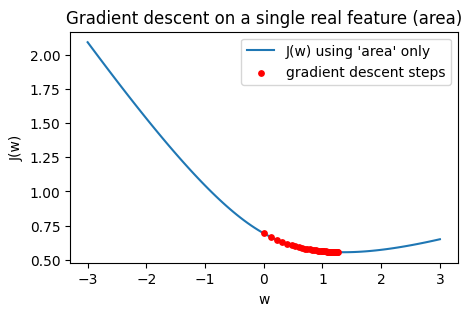

w after 40 steps: 1.2577
Cost after 40 steps: 0.5556  vs initial: 0.6931


In [ ]:
area_col_idx = feature_cols.index("area")
x_area = X_train[area_col_idx:area_col_idx+1, :]   # shape (1, m), standardized area only

def cost_given_w(w_scalar):
    A = sigmoid(w_scalar * x_area)
    return compute_cost(A, Y_train)

def grad_given_w(w_scalar):
    A = sigmoid(w_scalar * x_area)
    dz = A - Y_train
    return np.sum(x_area * dz) / x_area.shape[1]

w = 0.0
alpha = 0.5
history_w, history_cost = [w], [cost_given_w(w)]

for i in range(40):
    w = w - alpha * grad_given_w(w)
    history_w.append(w)
    history_cost.append(cost_given_w(w))

plt.figure(figsize=(5, 3))
w_range = np.linspace(-3, 3, 100)
plt.plot(w_range, [cost_given_w(wv) for wv in w_range], label="J(w) using 'area' only")
plt.scatter(history_w, history_cost, color="red", zorder=5, s=15, label="gradient descent steps")
plt.xlabel("w"); plt.ylabel("J(w)")
plt.title("Gradient descent on a single real feature (area)")
plt.legend()
plt.show()

print("w after 40 steps:", round(history_w[-1], 4))
print("Cost after 40 steps:", round(history_cost[-1], 4), " vs initial:", round(history_cost[0], 4))

In [ ]:
# Verify the dL/dz = a - y shortcut numerically, using one real training example
x1_ex, x2_ex = X_train[0, 0], X_train[1, 0]
y_ex = Y_train[0, 0]
w1, w2, b_ex = 0.4, -0.2, 0.1

def loss_of(w1, w2, b):
    z = w1 * x1_ex + w2 * x2_ex + b
    a = sigmoid(z)
    a = np.clip(a, 1e-8, 1 - 1e-8)
    return -(y_ex * np.log(a) + (1 - y_ex) * np.log(1 - a))

# analytic
z_ex = w1 * x1_ex + w2 * x2_ex + b_ex
a_ex = sigmoid(z_ex)
dL_dz_analytic = a_ex - y_ex

# numerical (finite difference on b, since dz/db = 1)
eps = 1e-6
dL_dz_numeric = (loss_of(w1, w2, b_ex + eps) - loss_of(w1, w2, b_ex - eps)) / (2 * eps)

print("Analytic dL/dz (= a - y):", dL_dz_analytic)
print("Numerical dL/dz:          ", dL_dz_numeric)

Analytic dL/dz (= a - y): 0.4978614901591996
Numerical dL/dz:           0.4978614900896794


In [ ]:
def logistic_regression_loop(X, Y, num_iterations=100, alpha=0.5, print_cost=False):
    n_x, m = X.shape
    w = np.zeros(n_x)
    b = 0.0
    costs = []

    for it in range(num_iterations):
        J = 0.0
        dw = np.zeros(n_x)
        db = 0.0

        for i in range(m):                       # loop over examples
            x_i = X[:, i]
            y_i = Y[0, i]

            z_i = b
            for j in range(n_x):                  # loop over features
                z_i += w[j] * x_i[j]
            a_i = sigmoid(z_i)

            a_i_clipped = min(max(a_i, 1e-8), 1 - 1e-8)
            J += -(y_i * np.log(a_i_clipped) + (1 - y_i) * np.log(1 - a_i_clipped))

            dz_i = a_i - y_i
            for j in range(n_x):
                dw[j] += x_i[j] * dz_i
            db += dz_i

        J  /= m
        dw /= m
        db /= m
        w -= alpha * dw
        b -= alpha * db
        costs.append(J)

        if print_cost and it % 20 == 0:
            print(f"iteration {it}: cost = {J:.4f}")

    return w, b, costs

t0 = time.time()
w_loop, b_loop, costs_loop = logistic_regression_loop(X_train, Y_train, num_iterations=100, alpha=0.5, print_cost=True)
t1 = time.time()
print(f"Loop version training time: {t1 - t0:.4f} sec")

iteration 0: cost = 0.6931
iteration 20: cost = 0.3566
iteration 40: cost = 0.3463
iteration 60: cost = 0.3440
iteration 80: cost = 0.3433
Loop version training time: 2.9015 sec


In [ ]:
n = 200_000
a_vec = np.random.rand(n)
b_vec = np.random.rand(n)

t0 = time.time()
dot = 0.0
for i in range(n):
    dot += a_vec[i] * b_vec[i]
t1 = time.time()
print(f"Loop dot product:       {1000*(t1-t0):.2f} ms")

t0 = time.time()
dot_vec = np.dot(a_vec, b_vec)
t1 = time.time()
print(f"Vectorized dot product: {1000*(t1-t0):.2f} ms")

Loop dot product:       238.56 ms
Vectorized dot product: 3.15 ms


In [ ]:
def forward_propagation(w, b, X):
    Z = np.dot(w.T, X) + b
    return sigmoid(Z)

w0 = np.zeros((n_x, 1))
A0 = forward_propagation(w0, 0.0, X_train)
print("A shape:", A0.shape)
print("First 5 predictions (all 0.5 since w=0):", A0[0, :5])

A shape: (1, 436)
First 5 predictions (all 0.5 since w=0): [0.5 0.5 0.5 0.5 0.5]


In [ ]:
def propagate(w, b, X, Y):
    m = X.shape[1]
    A = sigmoid(np.dot(w.T, X) + b)
    cost = compute_cost(A, Y)
    dZ = A - Y
    dw = (1.0 / m) * np.dot(X, dZ.T)
    db = (1.0 / m) * np.sum(dZ)
    return {"dw": dw, "db": db}, cost

def logistic_regression_vectorized(X, Y, num_iterations=500, alpha=0.5, print_cost=False):
    n_x = X.shape[0]
    w = np.zeros((n_x, 1))
    b = 0.0
    costs = []
    for it in range(num_iterations):
        grads, cost = propagate(w, b, X, Y)
        w -= alpha * grads["dw"]
        b -= alpha * grads["db"]
        costs.append(cost)
        if print_cost and it % 100 == 0:
            print(f"iteration {it}: cost = {cost:.4f}")
    return w, b, costs

t0 = time.time()
w_vec, b_vec, costs_vec = logistic_regression_vectorized(X_train, Y_train, num_iterations=500, alpha=0.5, print_cost=True)
t1 = time.time()
print(f"Vectorized training time (500 iterations): {t1 - t0:.4f} sec")

iteration 0: cost = 0.6931
iteration 100: cost = 0.3430
iteration 200: cost = 0.3429
iteration 300: cost = 0.3429
iteration 400: cost = 0.3429
Vectorized training time (500 iterations): 0.1088 sec


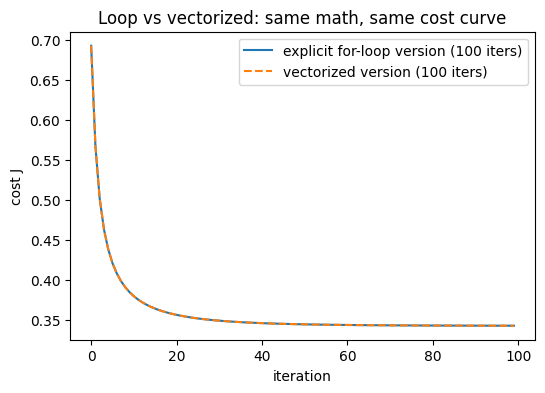

Final cost, loop (100 iters):       0.34302
Final cost, vectorized (100 iters): 0.34302


In [ ]:
# Compare against the loop version run for the same number of iterations it actually did (100)
w_vec100, b_vec100, costs_vec100 = logistic_regression_vectorized(X_train, Y_train, num_iterations=100, alpha=0.5)

plt.figure(figsize=(6, 4))
plt.plot(costs_loop, label="explicit for-loop version (100 iters)")
plt.plot(costs_vec100, label="vectorized version (100 iters)", linestyle="--")
plt.xlabel("iteration"); plt.ylabel("cost J")
plt.title("Loop vs vectorized: same math, same cost curve")
plt.legend()
plt.show()

print("Final cost, loop (100 iters):      ", round(costs_loop[-1], 5))
print("Final cost, vectorized (100 iters):", round(costs_vec100[-1], 5))

Training accuracy: 84.17%
Test accuracy:     82.57%


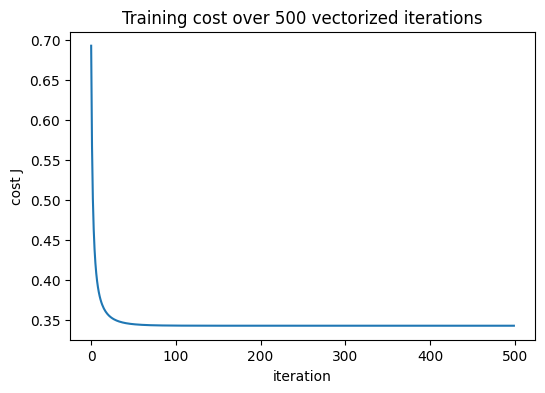

In [ ]:
def predict(w, b, X, threshold=0.5):
    A = sigmoid(np.dot(w.T, X) + b)
    return (A > threshold).astype(int)

train_preds = predict(w_vec, b_vec, X_train)
test_preds  = predict(w_vec, b_vec, X_test)

train_acc = np.mean(train_preds == Y_train) * 100
test_acc  = np.mean(test_preds == Y_test) * 100

print(f"Training accuracy: {train_acc:.2f}%")
print(f"Test accuracy:     {test_acc:.2f}%")

plt.figure(figsize=(6, 4))
plt.plot(costs_vec)
plt.xlabel("iteration"); plt.ylabel("cost J")
plt.title("Training cost over 500 vectorized iterations")
plt.show()